In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "nts_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "./configs/nts_conservative_batch48_trial1.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from descriptor import Desctiptor
des = Desctiptor()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = int(config["batch_size"])
TOTAL_EVAL = int(config["total_eval"])
INITIAL_BATCH_SIZE = int(config["initial_batch_size"])
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

CyclesNum: 14
Mode.conservative


PosixPath('data_conservative_batch48_trial1/nts_conservative_batch48_trial1.yaml')

In [9]:
candidates_file = out_dir / f"descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"descriptor_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()

    #実験終了後，測定データを解析し，目的関数をアップデートする
    import analysis_output_functions_SO_descriptor
    analysis_output_functions_SO_descriptor.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!


Proposals
###
number = 1
actions =  6971
proposal =  [2.6 1.2 1.5]
###
###
number = 2
actions =  10353
proposal =  [3.6 1.3 3. ]
###
###
number = 3
actions =  16184
proposal =  [3.2 1.5 1.5]
###
###
number = 4
actions =  6363
proposal =  [0.9 1.2 3.6]
###
###
number = 5
actions =  13028
proposal =  [2.8 1.4 0.4]
###
###
number = 6
actions =  13663
proposal =  [4.5 1.4 1. ]
###
###
number = 7
actions =  5558
proposal =  [6.9 1.1 0.8]
###
###
number = 8
actions =  6344
proposal =  [0.9 1.2 1.7]
###
###
number = 9
actions =  13816
proposal =  [4.9 1.4 1.5]
###
###
number = 10
actions =  7526
proposal =  [4.1 1.2 1.5]
###
###
number = 11
actions =  6006
proposal =  [0.  1.2 1.2]
###
###
number = 12
actions =  15171
proposal =  [0.5 1.5 0.1]
###
###
number = 13
actions =  13639
proposal =  [4.4 1.4 2.3]
###
###
number = 14
actions =  12567
proposal =  [1.5 1.4 2.4]
###
###
number = 15
actions =  9101
proposal =  [0.2 1.3 3.6]
###
###
number = 16
actions =  12390
proposal =  [1.  1.4 3.2]
##

Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 1.1531379482000002


Selected actions: [np.int64(2743), np.int64(11678), np.int64(17097), np.int64(2856), np.int64(17596), np.int64(14183), np.int64(8859), np.int64(11307), np.int64(7288), np.int64(16386), np.int64(14264), np.int64(17662), np.int64(6002), np.int64(1465), np.int64(11448), np.int64(11495), np.int64(11188), np.int64(14520), np.int64(14715), np.int64(4038), np.int64(5346), np.int64(11340), np.int64(6045), np.int64(2931), np.int64(14294), np.int64(17380), np.int64(14369), np.int64(17405), np.int64(14413), np.int64(11774), np.int64(5646), np.int64(6182), np.int64(11889), np.int64(17909), np.int64(16727), np.int64(6222), np.int64(1599), np.int64(9108), np.int64(11369), np.int64(12213), np.int64(14637), np.int64(14631), np.int64(17900), np.int64(11532), np.int64(14117), np.int64(1688), np.int64(2635), np.int64(6192)]
Proposals
###
number = 1
actions =  2743
proposal =  [7.4 1.  0.5]
###
###
number = 2
actions =  11678
proposal =  [7.2 1.3 2.3]
###
###
number = 3
actions =  17097
proposal =  [5.7 1

...

lstar: 1.1885593402


Selected actions: [np.int64(6613), np.int64(16042), np.int64(10848), np.int64(11648), np.int64(12035), np.int64(17823), np.int64(10732), np.int64(17538), np.int64(16228), np.int64(1838), np.int64(952), np.int64(9372), np.int64(24), np.int64(6723), np.int64(480), np.int64(7411), np.int64(14423), np.int64(6894), np.int64(17572), np.int64(16227), np.int64(230), np.int64(4541), np.int64(10779), np.int64(10699), np.int64(16466), np.int64(15967), np.int64(15606), np.int64(17848), np.int64(12037), np.int64(1896), np.int64(10769), np.int64(3037), np.int64(15470), np.int64(16968), np.int64(14721), np.int64(2916), np.int64(7410), np.int64(13901), np.int64(507), np.int64(12000), np.int64(9631), np.int64(15120), np.int64(12584), np.int64(17077), np.int64(15632), np.int64(14878), np.int64(16844), np.int64(16360)]
Proposals
###
number = 1
actions =  6613
proposal =  [1.6 1.2 2.7]
###
###
number = 2
actions =  16042
proposal =  [2.8 1.5 2.1]
###
###
number = 3
actions =  10848
proposal =  [5.  1.3 0.

lstar: 1.1973830764999998


Selected actions: [np.int64(16209), np.int64(15918), np.int64(17652), np.int64(15394), np.int64(6129), np.int64(1396), np.int64(16310), np.int64(10836), np.int64(15609), np.int64(8948), np.int64(17886), np.int64(5945), np.int64(13363), np.int64(954), np.int64(17346), np.int64(2946), np.int64(17535), np.int64(17615), np.int64(12327), np.int64(6411), np.int64(12651), np.int64(16346), np.int64(10869), np.int64(15043), np.int64(13214), np.int64(16104), np.int64(13075), np.int64(16219), np.int64(10452), np.int64(7982), np.int64(14540), np.int64(16026), np.int64(12723), np.int64(8027), np.int64(13038), np.int64(2909), np.int64(16344), np.int64(14567), np.int64(10267), np.int64(5754), np.int64(8740), np.int64(9435), np.int64(9360), np.int64(5302), np.int64(15570), np.int64(15466), np.int64(9017), np.int64(15421)]
Proposals
###
number = 1
actions =  16209
proposal =  [3.3 1.5 0.3]
###
###
number = 2
actions =  15918
proposal =  [2.5 1.5 0.8]
###
###
number = 3
actions =  17652
proposal =  [7.2

Elapsed time: 33046.17696809769 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])


Text(0, 0.5, 'Objective')

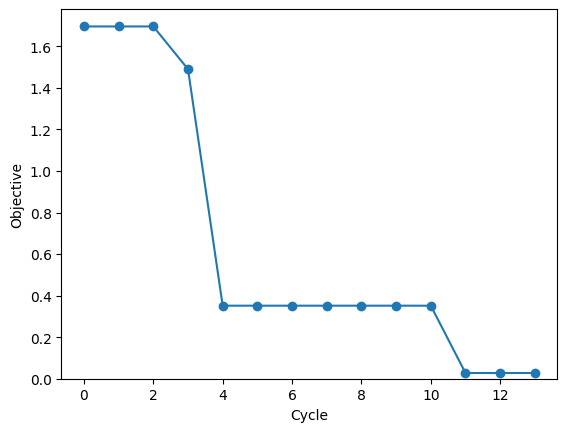

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)